# Лабораторная работа  
## Анализ и визуализация данных об успеваемости студентов

**Студент (ФИО + ИСУ): Чы Нгок Чыонг 473229**  
**Группа: P3123**  
**Дата: 02/05/2026**

---

### Что нужно сделать
Заполните этот notebook по шагам:
1. загрузите датасет;
2. выполните первичный анализ;
3. обработайте данные;
4. создайте новые признаки;
5. выполните группировку и агрегацию;
6. постройте графики;
7. сделайте выводы.

> В большинстве ячеек код нужно написать самостоятельно.

## 1. Импорт библиотек

Импортируйте библиотеки, которые понадобятся в работе.

Минимально ожидается использование:
- `pandas`
- `matplotlib.pyplot`

При необходимости можно добавить и другие библиотеки.

In [1]:
# Напишите импорт библиотек здесь
import pandas as pd
import matplotlib.pyplot as plt

## 2. Загрузка данных

Считайте CSV-файл в `DataFrame`.

Ожидается, что датасет лежит по относительному пути:
`data/StudentsPerformance.csv`

После загрузки данных выведите:
- первые 5 строк;
- размер таблицы.

In [2]:
# Загрузите датасет и выведите первые строки и размер таблицы
df = pd.read_csv('data/data_StudentsPerformance.csv')

print('Первые 5 строк таблицы:')
display(df.head())

print('Размер таблицы:')
print(df.shape)

Первые 5 строк таблицы:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Размер таблицы:
(1000, 8)


## 3. Первичный просмотр структуры данных

На этом этапе нужно посмотреть:
- названия столбцов;
- типы данных;
- базовую информацию о таблице.

Подумайте:
- какие признаки числовые;
- какие признаки категориальные.

In [3]:
# Выведите названия столбцов, типы данных и базовую информацию о таблице
print('Названия столбцов:')
print(df.columns.tolist())

print('\nТипы данных:')
print(df.dtypes)

print('\nБазовая информация о таблице:')
df.info()

Названия столбцов:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Типы данных:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Базовая информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation cours

## 4. Проверка пропущенных значений

Проверьте, есть ли в таблице пустые значения.

Кратко прокомментируйте результат:
- есть ли пропуски;
- в каких столбцах они находятся;
- требуется ли обработка.

In [4]:
# Проверьте пропущенные значения
missing_values = df.isnull().sum()
print('Количество пропущенных значений по столбцам:')
print(missing_values)

print('\nОбщее количество пропущенных значений:')
print(df.isnull().sum().sum())

Количество пропущенных значений по столбцам:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Общее количество пропущенных значений:
0


### Краткий комментарий
Напишите 1–3 предложения о результате проверки пропусков.

В датасете отсутствуют пропущенные значения во всех столбцах. Это означает, что дополнительная обработка пропусков не требуется, и данные можно сразу использовать для дальнейшего анализа.

## 5. Переименование столбцов

Приведите названия столбцов к более удобному виду.

Рекомендуется:
- убрать пробелы;
- заменить специальные символы;
- использовать короткие и понятные имена.

Пример подхода:
- `math score` → `math_score`
- `test preparation course` → `test_prep`

После переименования снова выведите список столбцов.

In [5]:
# Переименуйте столбцы и выведите обновленный список
df = df.rename(columns={
    'gender': 'gender',
    'race/ethnicity': 'race_ethnicity',
    'parental level of education': 'parent_education',
    'lunch': 'lunch',
    'test preparation course': 'test_prep',
    'math score': 'math_score',
    'reading score': 'reading_score',
    'writing score': 'writing_score'
})

print('Обновленный список столбцов:')
print(df.columns.tolist())


Обновленный список столбцов:
['gender', 'race_ethnicity', 'parent_education', 'lunch', 'test_prep', 'math_score', 'reading_score', 'writing_score']


## 6. Создание новых признаков

На этом этапе нужно самостоятельно создать **не менее одного нового признака** на основе существующих столбцов.

Обязательный вариант:
- `average_score` — средний балл по трем предметам.

Можно добавить и другие признаки, если считаете это полезным.

In [6]:
# Создайте новый признак (минимум один)
df['average_score'] = df[['math_score', 'reading_score', 'writing_score']].mean(axis=1)

# Дополнительный признак: общий уровень результата студента
def score_level(score):
    if score >= 80:
        return 'high'
    elif score >= 60:
        return 'medium'
    else:
        return 'low'

df['score_level'] = df['average_score'].apply(score_level)

display(df.head())

,gender,race_ethnicity,parent_education,lunch,test_prep,math_score,reading_score,writing_score,average_score,score_level
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,medium
1,female,group C,some college,standard,completed,69,90,88,82.333333,high
2,female,group B,master's degree,standard,none,90,95,93,92.666667,high
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,low
4,male,group C,some college,standard,none,76,78,75,76.333333,medium


## 7. Описательная статистика

Постройте базовую статистику по числовым признакам.

Подумайте:
- какие значения являются типичными;
- есть ли большой разброс;
- какие признаки удобно анализировать дальше.

In [7]:
# Выведите описательную статистику
display(df.describe())

,math_score,reading_score,writing_score,average_score
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667
std,15.16308,14.600192,15.195657,14.257326
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.333333
50%,66.00000,70.000000,69.000000,68.333333
75%,77.00000,79.000000,79.000000,77.666667
max,100.00000,100.000000,100.000000,100.000000


### Краткий комментарий
Напишите 2–4 предложения по результатам описательной статистики.

Средние значения по всем предметам находятся в диапазоне примерно 66–69 баллов, что говорит о среднем уровне успеваемости студентов. Разброс значений (std около 14–15) показывает, что результаты достаточно разнообразны. Минимальные и максимальные значения сильно различаются (от 0 до 100), что указывает на наличие как очень слабых, так и отличных результатов среди студентов.

## 8. Выделение числовых и категориальных признаков

Сформируйте отдельно:
- список числовых признаков;
- список категориальных признаков.

In [8]:
# Получите списки числовых и категориальных признаков

numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print('Числовые признаки:')
print(numeric_cols)

print('\nКатегориальные признаки:')
print(categorical_cols)

Числовые признаки:
['math_score', 'reading_score', 'writing_score', 'average_score']

Категориальные признаки:
['gender', 'race_ethnicity', 'parent_education', 'lunch', 'test_prep', 'score_level']


## 9. Группировка и агрегация

Выполните группировку данных и вычислите агрегированные показатели.

Минимально нужно посчитать:
- средний балл по `test_prep`;
- средний балл по `gender`;
- средний балл по `parent_education`.

При необходимости можно добавить дополнительные группировки.

In [9]:
# Выполните группировку и вычислите средние значения
print('Средний балл по test_prep:')
test_prep_mean = df.groupby('test_prep')['average_score'].mean().sort_values(ascending=False)
display(test_prep_mean)

print('Средний балл по gender:')
gender_mean = df.groupby('gender')['average_score'].mean().sort_values(ascending=False)
display(gender_mean)

print('Средний балл по parent_education:')
parent_education_mean = df.groupby('parent_education')['average_score'].mean().sort_values(ascending=False)
display(parent_education_mean)

Средний балл по test_prep:


test_prep
completed    72.669460
none         65.038941
Name: average_score, dtype: float64

Средний балл по gender:


gender
female    69.569498
male      65.837483
Name: average_score, dtype: float64

Средний балл по parent_education:


parent_education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.569069
some college          68.476401
some high school      65.108007
high school           63.096939
Name: average_score, dtype: float64

### Краткий комментарий
Опишите, какие различия между группами удалось заметить.

### Краткий комментарий

Студенты, прошедшие подготовительный курс (test_prep), имеют заметно более высокий средний балл, чем те, кто его не проходил. Также видно, что в среднем девушки показывают немного лучшие результаты, чем юноши. Кроме того, уровень образования родителей влияет на успеваемость: чем выше образование, тем выше средний балл студентов.

## 10. Визуализация 1 — гистограмма

Постройте гистограмму для одного из числовых признаков.

Обязательный вариант:
- `math_score`

Не забудьте:
- заголовок;
- подпись оси X;
- подпись оси Y;
- сетку при необходимости.

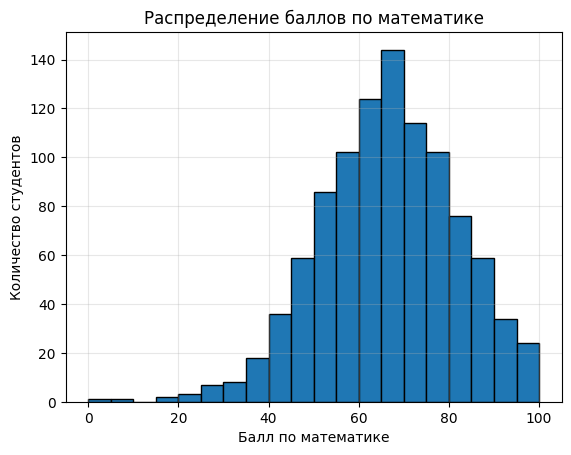

In [10]:
# Постройте гистограмму
plt.hist(df['math_score'], bins=20, edgecolor='black')
plt.title('Распределение баллов по математике')
plt.xlabel('Балл по математике')
plt.ylabel('Количество студентов')
plt.grid(True, alpha=0.3)
plt.show()

### Вывод по графику
Напишите 1–3 предложения.

### Вывод по графику

Распределение баллов по математике имеет форму, близкую к нормальному распределению, с пиком в районе 60–70 баллов. Большинство студентов набирают средние значения, при этом очень низкие и очень высокие результаты встречаются реже.

## 11. Визуализация 2 — столбчатая диаграмма

Постройте столбчатую диаграмму среднего балла по `test_prep`.

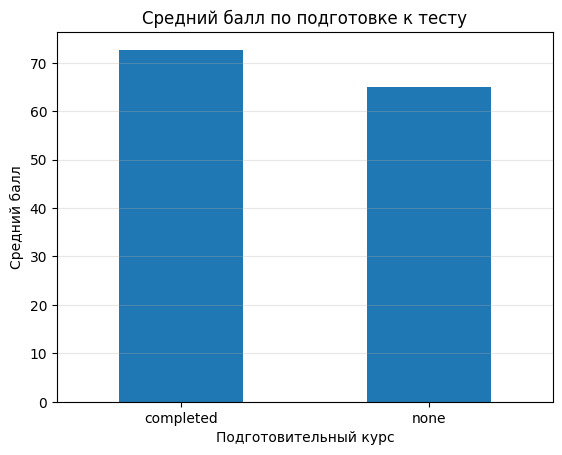

In [11]:
# Постройте столбчатую диаграмму по test_prep
test_prep_mean.plot(kind='bar')
plt.title('Средний балл по подготовке к тесту')
plt.xlabel('Подготовительный курс')
plt.ylabel('Средний балл')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Вывод по графику
Напишите 1–3 предложения.

### Вывод по графику

Студенты, завершившие подготовительный курс, в среднем показывают более высокие результаты. Это подтверждает, что дополнительная подготовка положительно влияет на успеваемость.

## 12. Визуализация 3 — столбчатая диаграмма

Постройте столбчатую диаграмму среднего балла по `gender`.

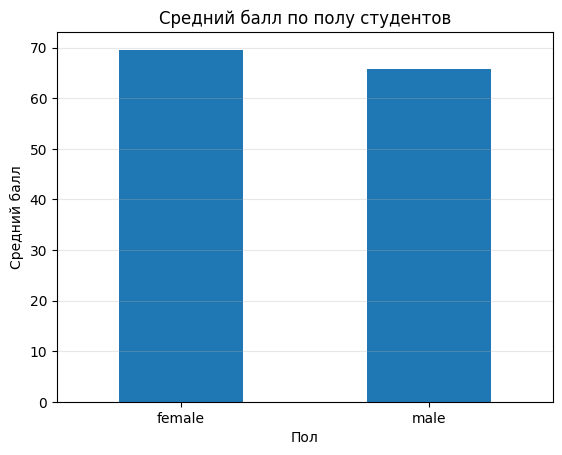

In [12]:
# Постройте столбчатую диаграмму по gender
gender_mean.plot(kind='bar')
plt.title('Средний балл по полу студентов')
plt.xlabel('Пол')
plt.ylabel('Средний балл')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Вывод по графику
Напишите 1–3 предложения.

### Вывод по графику

В среднем девушки показывают немного более высокие результаты, чем юноши. Однако разница не является очень большой.

## 13. Визуализация 4 — диаграмма рассеяния

Постройте диаграмму рассеяния для зависимости между двумя числовыми признаками.

Обязательный вариант:
- `math_score` и `reading_score`

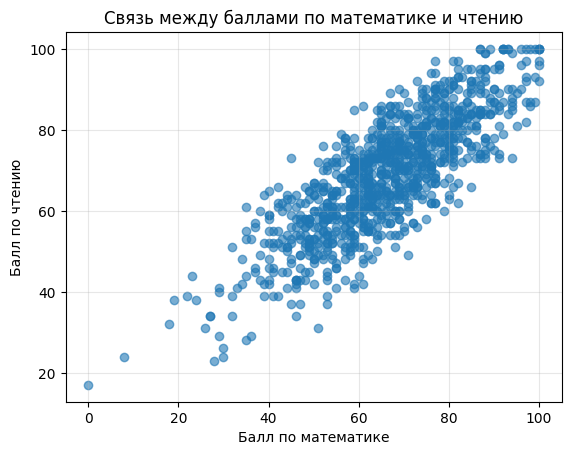

In [13]:
# Постройте диаграмму рассеяния
plt.scatter(df['math_score'], df['reading_score'], alpha=0.6)
plt.title('Связь между баллами по математике и чтению')
plt.xlabel('Балл по математике')
plt.ylabel('Балл по чтению')
plt.grid(True, alpha=0.3)
plt.show()

### Вывод по графику
Напишите 1–3 предложения.

### Вывод по графику

Наблюдается явная положительная зависимость между баллами по математике и чтению. Это означает, что студенты с высокими результатами по одному предмету, как правило, показывают хорошие результаты и по другому.

## 14. Дополнительная визуализация

Добавьте **еще один график самостоятельно**.

Можно выбрать один из вариантов:
- график по `parent_education`;
- график по `lunch`;
- boxplot;
- еще одна гистограмма;
- другой осмысленный вариант.

Построим дополнительный график: средний балл по уровню образования родителей.

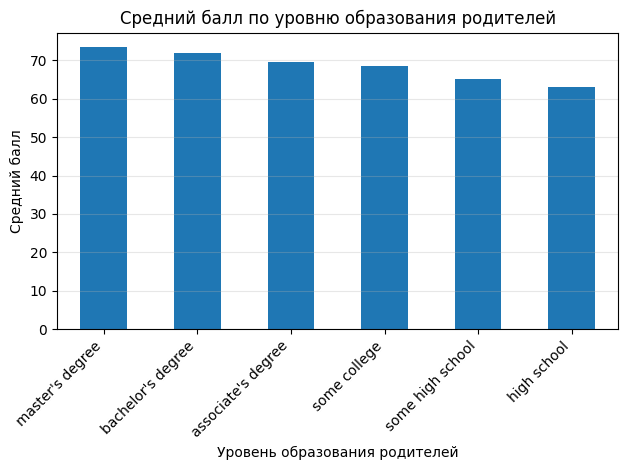

In [14]:
# Постройте дополнительный график
parent_education_mean.plot(kind='bar')
plt.title('Средний балл по уровню образования родителей')
plt.xlabel('Уровень образования родителей')
plt.ylabel('Средний балл')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Вывод по графику
Напишите 1–3 предложения.

### Вывод по графику

Наблюдается чёткая зависимость между уровнем образования родителей и успеваемостью студентов. Чем выше уровень образования родителей, тем выше средний балл студентов. Студенты, чьи родители имеют степень магистра или бакалавра, показывают лучшие результаты по сравнению с остальными.

## 15. Итоговый вывод

В финале кратко ответьте:
1. Что было сделано в работе?
2. Какие библиотеки и методы были использованы?
3. Какие закономерности удалось заметить?
4. Какие трудности возникли в процессе выполнения?

В ходе лабораторной работы был загружен датасет об успеваемости студентов, выполнен первичный анализ структуры данных, проверены пропущенные значения и переименованы столбцы. Также были созданы новые признаки `average_score` и `score_level`, выполнены группировки и построены графики с использованием библиотек `pandas` и `matplotlib`.

В результате анализа удалось заметить, что подготовка к тесту может быть связана с более высоким средним баллом. Также были рассмотрены различия в успеваемости по полу и уровню образования родителей. Основная трудность работы заключалась в правильной организации notebook, чтобы каждый этап был понятным и сопровождался выводами.

## 16. Проверка перед сдачей

Перед отправкой убедитесь, что:
- все ячейки выполняются без ошибок;
- код написан последовательно и понятно;
- новые признаки действительно созданы вами;
- столбцы переименованы;
- построено не менее 4 обязательных графиков;
- под каждым графиком есть вывод;
- notebook сохранен после выполнения `Restart & Run All`.